In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [2]:
df = pd.read_csv("data/raw/Media-Matrix-Combined-v4-moles-per-litre-annotate.csv")

# run this to remove these compounds from analysis
# filter rows that were considered not important
compounds_to_remove = [
    'Dipotassium phosphate', 'Disodium edta dihydrate', 'EDTA', 'Monopotassium phosphate',
    'Phosphoric acid', 'Potassium hydroxide', 'Sodium citrate dihydrate', 'Sodium phosphate',
    'Sulphuric acid', 'Uracil'
]
df = df[~df['Compound'].isin(compounds_to_remove)].copy()

# remove pubchemid
df.drop(df.columns[1], axis=1, inplace=True)

# separate numeric columns for transformation
num_df = df.select_dtypes(include='number')
labels = df[['Compound', 'Annotate']]

pseudocount = 1e-10
num_df=np.log10(num_df.replace(0, pseudocount))

df_log = pd.concat([labels, num_df], axis=1)

yar_df = df_log.filter(like='_YAR')
#cer_df = df_log.filter(like='_CER')
#pic_df = df_log.filter(like='_PIC')

yar_df_labeled = pd.concat([labels, yar_df], axis=1)

# Define which columns are sample measurements (everything except metadata)
sample_cols = yar_df_labeled.columns.difference(['Compound', 'Annotate'])

# Filter to keep rows where at least one sample value ≠ -10
yar_df_labeled = yar_df_labeled[
    yar_df_labeled['Annotate'].isin(['Vitamin', 'Element']) &
    ~(yar_df_labeled[sample_cols] == -10).all(axis=1)
].copy()

# let's remove redundant elements for calcium iron, manganese, sodium chloride and zinc chloride
yar_df_labeled = yar_df_labeled.drop(index=[9, 16, 29, 35, 46, 59])

yar_df_element = yar_df_labeled[yar_df_labeled['Annotate'] == 'Element'].copy()
yar_df_vitamin = yar_df_labeled[yar_df_labeled['Annotate'] == 'Vitamin'].copy()

In [3]:
# Set up
df_v = yar_df_vitamin.copy()
sample_cols = df_v.columns.difference(['Compound', 'Annotate'])

# Initialize list for results
ratios = []

# All unique compound pairs
compound_pairs = list(itertools.combinations(df_v['Compound'], 2))

# Map for quick lookup
compound_map = df_v.set_index('Compound')[sample_cols]

# Loop through pairs
for c1, c2 in compound_pairs:
    vals1 = compound_map.loc[c1]
    vals2 = compound_map.loc[c2]

    # Per-column mask
    valid_mask = (vals1 > -10) & (vals2 > -10)
    log_ratio = vals1 - vals2  # keeps all columns

    # Only keep valid entries
    log_ratio_filtered = log_ratio.where(valid_mask)

    # Store as a row with all per-column ratios
    row = {
        'Compound_1': c1,
        'Compound_2': c2,
        **log_ratio_filtered.to_dict()  # unpack sample-wise ratios
    }
    ratios.append(row)

# Create DataFrame
ratio_df_v = pd.DataFrame(ratios)

In [ ]:
# drop these as they are simply repeats (this study varies carbon and nitrogen source which will be constant for our purposes)
ratio_df_v_reduced = ratio_df_v.drop(columns=['2b_YAR', '2c_YAR', '2d_YAR'])

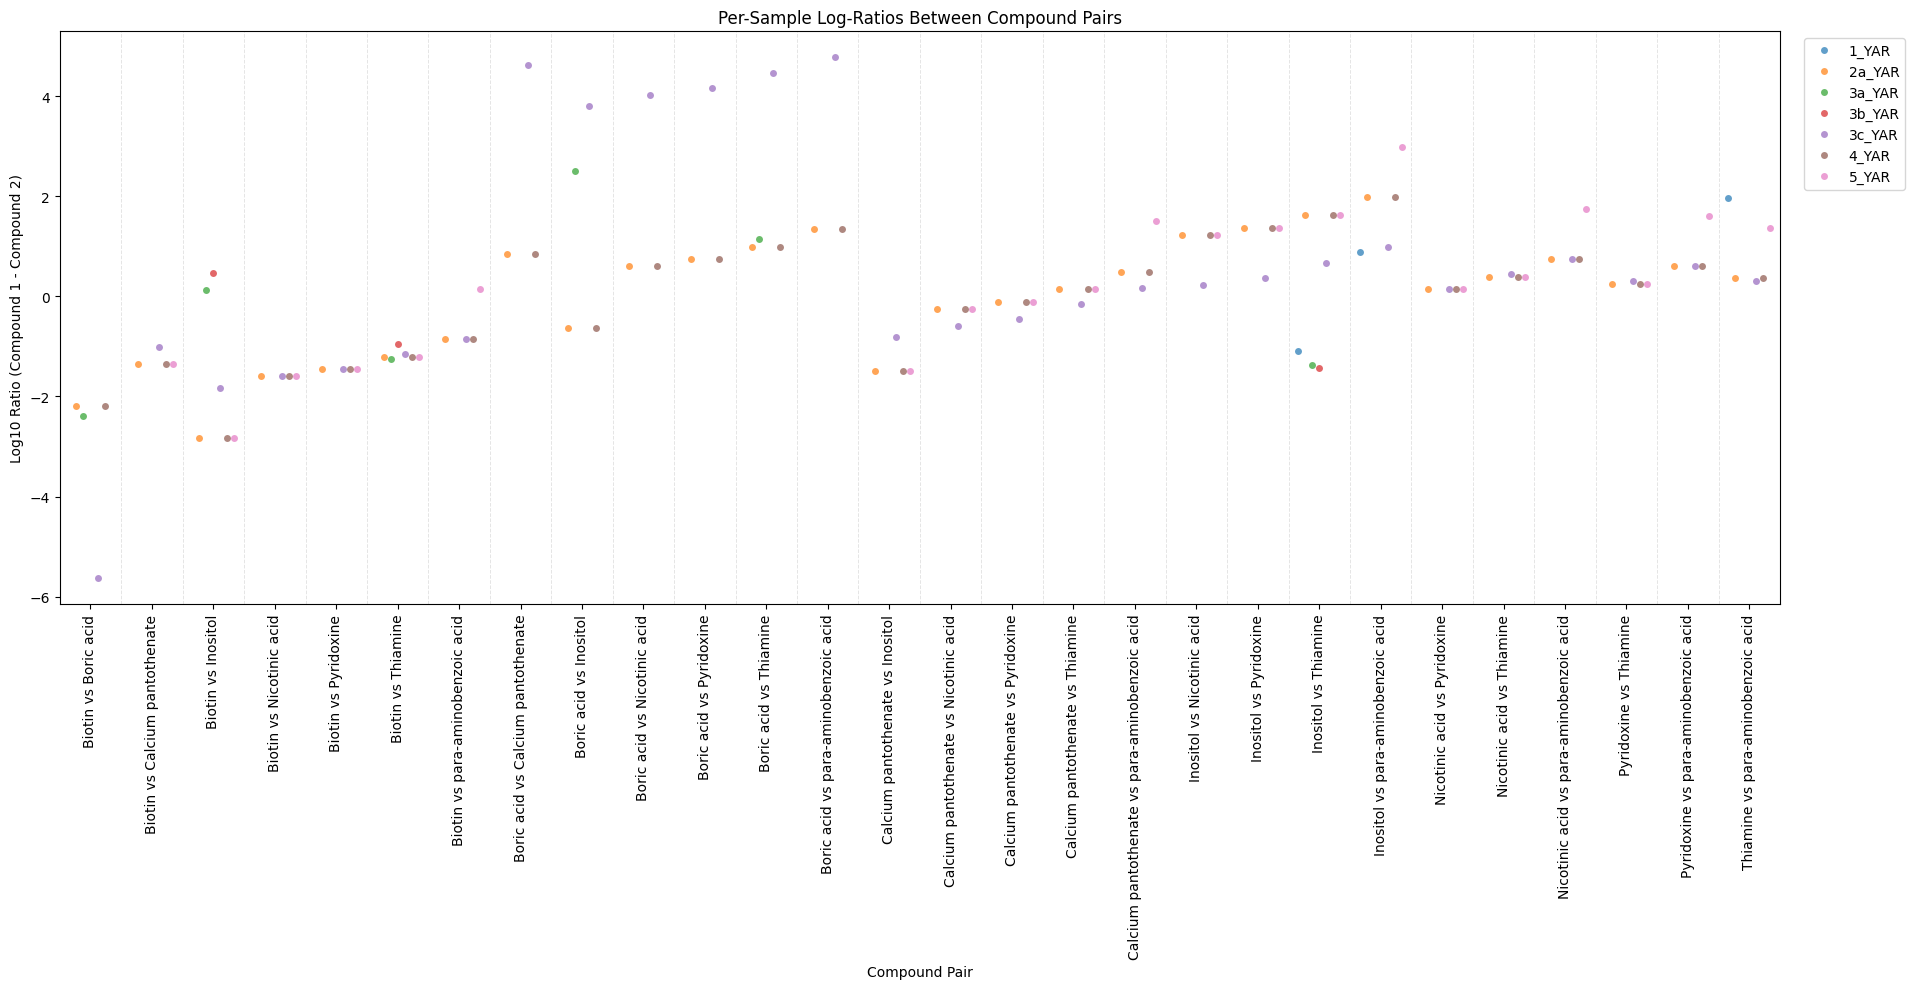

In [5]:
ratio_long = pd.melt(
    ratio_df_v_reduced,
    id_vars=['Compound_1', 'Compound_2'],
    var_name='Sample',
    value_name='Log_Ratio'
)

# Combine compound pair into a single string for plotting
ratio_long['Pair'] = ratio_long['Compound_1'] + " vs " + ratio_long['Compound_2']

plt.figure(figsize=(18, 10))

sns.stripplot(
    data=ratio_long,
    x='Pair',
    y='Log_Ratio',
    hue='Sample',
    jitter=True,
    dodge=True,
    alpha=0.7
)


plt.xticks(rotation=90)
plt.ylabel("Log10 Ratio (Compound 1 - Compound 2)")
plt.xlabel("Compound Pair")
plt.title("Per-Sample Log-Ratios Between Compound Pairs")
plt.tight_layout()
n_categories = len(plt.gca().get_xticks())
for x in np.arange(0.5, n_categories, 1):
    plt.axvline(x=x, color='lightgray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

In [6]:
# Select only numeric columns
numeric_cols = ratio_df_v_reduced.select_dtypes(include='number').columns

# Create new DataFrame with range values
range_df_v = pd.DataFrame({
    'Compound_1': ratio_df_v_reduced['Compound_1'],
    'Compound_2': ratio_df_v_reduced['Compound_2'],
    # Compute row-wise max-min
    'range': ratio_df_v_reduced[numeric_cols].max(axis=1) - ratio_df_v_reduced[numeric_cols].min(axis=1)
})
'''
import os

# Create the 'results' folder if it doesn't exist
os.makedirs('results', exist_ok=True)

range_df_v.to_csv('results/compound_pair_ranges_vitamin.csv', index=False)
'''

"\nimport os\n\n# Create the 'results' folder if it doesn't exist\nos.makedirs('results', exist_ok=True)\n\nrange_df_v.to_csv('results/compound_pair_ranges_vitamin.csv', index=False)\n"

In [7]:
range_df_v.head()

,Compound_1,Compound_2,range
0,Biotin,Boric acid,3.425968
1,Biotin,Calcium pantothenate,0.337163
2,Biotin,Inositol,3.301031
3,Biotin,Nicotinic acid,0.000000
4,Biotin,Pyridoxine,0.000000


In [8]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Create a square distance matrix
compounds = pd.unique(range_df_v[['Compound_1', 'Compound_2']].values.ravel())
distance_matrix = pd.DataFrame(0, index=compounds, columns=compounds, dtype=float)

# Fill in distances
for _, row in range_df_v.iterrows():
    c1, c2, dist = row['Compound_1'], row['Compound_2'], row['range']
    distance_matrix.loc[c1, c2] = dist
    distance_matrix.loc[c2, c1] = dist  # Make it symmetric

In [9]:
condensed_dist = squareform(distance_matrix.values)

In [10]:
Z = linkage(condensed_dist, method='average')  # or 'ward', 'single', etc.


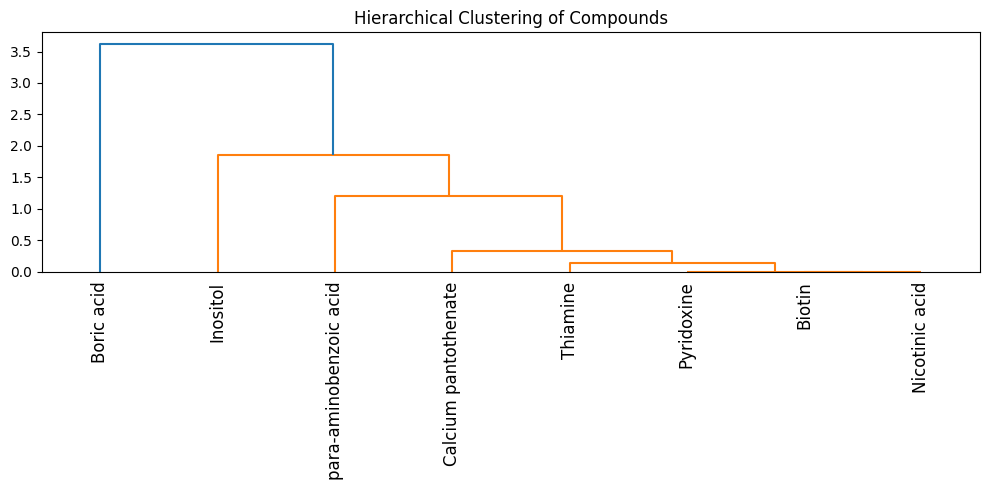

In [11]:
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=distance_matrix.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering of Compounds")
plt.tight_layout()
plt.show()
